In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

The data sets used in this notebook will be two, studied separately but then later merged as ty contain crucial information to the same issue, i reckon its like columns used in the same dataset but te are in different CSVs.

In [2]:
#upload the data and view some of its caracteristics in summary
confirmed_set=pd.read_csv("C:/Users/small/Downloads/time_series_covid19_confirmed_global.csv")
confirmed_set.info()
confirmed_set.head()
confirmed_set.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.5+ MB


Province/State    198
Country/Region      0
Lat                 2
Long                2
1/22/20             0
                 ... 
3/5/23              0
3/6/23              0
3/7/23              0
3/8/23              0
3/9/23              0
Length: 1147, dtype: int64

From dot info, we get an idea that the set ahs lot of columns (1147), with only 4 being different and te remain amount being dates seemingly each day till 3/9/23. So the display is truncated. 
Dates consistently seem to ave no missing values but Province/State has more tan 50% missing, lat and long both have 2.

But such a dataset can be turned into something of long format compared to currently what can be considered wide, where date is a column in itself, not every date being a column, also suitable formodels like ARIMA where time can then be used as an index.

In [3]:
deaths_set = pd.read_csv("C:/Users/small/Downloads/covid19_deaths_global.csv")
deaths_set.info()
deaths_set.head()
deaths_set.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.5+ MB


Province/State    198
Country/Region      0
Lat                 2
Long                2
1/22/20             0
                 ... 
3/5/23              0
3/6/23              0
3/7/23              0
3/8/23              0
3/9/23              0
Length: 1147, dtype: int64

What was noticed with the confirmed set seems to be the case for death set as well, so from both sets the next step is to convert both to long formats, to make them EDA friendly.

In [4]:
#long format shaping
confirmed_long = confirmed_set.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"], var_name="Date", value_name="Confirmed")

deaths_long = deaths_set.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"], var_name="Date", value_name="Deaths")

#convert the dates
confirmed_long["Date"] = pd.to_datetime(confirmed_long["Date"], format="%m/%d/%y")
deaths_long["Date"] = pd.to_datetime(deaths_long["Date"], format="%m/%d/%y")

In [5]:
#merge the two datasets (deaths_long and confirmed_long)
merged_set = pd.merge(
    confirmed_long,
    deaths_long,
    on=["Province/State", "Country/Region", "Lat", "Long", "Date"],how="inner")

#confirm
merged_set.head()
merged_set.info()
merged_set.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330327 entries, 0 to 330326
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Province/State  104013 non-null  object        
 1   Country/Region  330327 non-null  object        
 2   Lat             328041 non-null  float64       
 3   Long            328041 non-null  float64       
 4   Date            330327 non-null  datetime64[ns]
 5   Confirmed       330327 non-null  int64         
 6   Deaths          330327 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 17.6+ MB


Province/State    226314
Country/Region         0
Lat                 2286
Long                2286
Date                   0
Confirmed              0
Deaths                 0
dtype: int64

aS ALREADY MENTIONED THERE ARE MISSING VALUES, PARTICULARLY FOR STATES AND PROVINCES AS SOME COUNTRIES DONT HAVE THESE IT MAKES SENSE THAT THE MISSING VALUES COUNT CAN BE SO HIGH. The idea is to fill in using "No State". Other missing values are in Lat and Long, since this are a very small fracton tey will be filled in with zero(0).

In [6]:
#filling in the missing values
merged_set["Lat"] = merged_set["Lat"].fillna(0)#these were filled in with zero due to ow smal in number they were
merged_set["Long"] = merged_set["Long"].fillna(0)
#missing values for state or province are a product of some countries not having these
merged_set["Province/State"] = merged_set["Province/State"].fillna("No State")

**Aggregation**
There are manyrows that feature the same country but it appears mmultiple times and so the a summary can be created from them. This allowed for the assessment at regional, coountry, and global levels.

In [7]:
#groupby country or region while minding the dates
countries = merged_set.groupby(["Country/Region", "Date"])[["Confirmed", "Deaths"]].sum().reset_index()

globe = merged_set.groupby("Date")[["Confirmed", "Deaths"]].sum().reset_index ()

#change fcrom object to categorivcal data

merged_set.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330327 entries, 0 to 330326
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Province/State  330327 non-null  object        
 1   Country/Region  330327 non-null  object        
 2   Lat             330327 non-null  float64       
 3   Long            330327 non-null  float64       
 4   Date            330327 non-null  datetime64[ns]
 5   Confirmed       330327 non-null  int64         
 6   Deaths          330327 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 17.6+ MB


Next is visualization at regional level
Contries in different corners of th world have been selected and will represent the regions in question.

**THIS WILL BE DONE THROUGH**

**Rolling(7) Mean**
Next is te statistics of the data, rolling mean, this means for a certain day, take the previous 6 days plus that day and find a mean of all of them togather. If this is increasing it shows a trend that the pandemic is increasing while removing the noise and fluctuations from te raw data that make it hard.

**Rolling STD Deviation**
This communicates the fluctuaions of a dataset, the volatility of it, and the higher it is the larger te fluctuations.

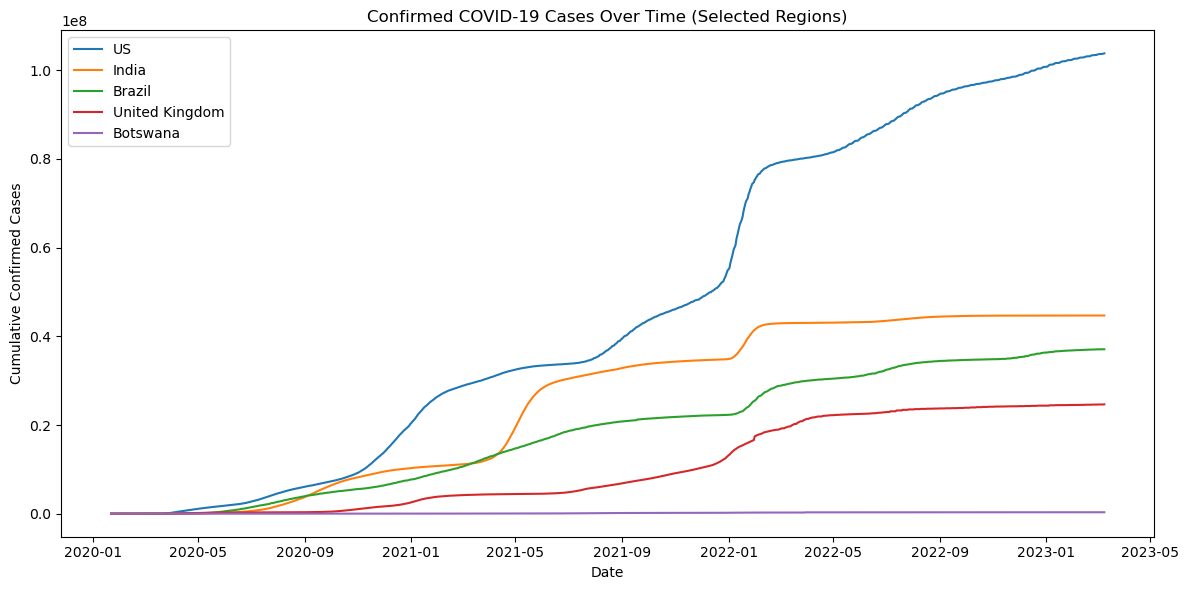

In [8]:
selected_countries = ["US", "India", "Brazil", "United Kingdom", "Botswana"]
#create 
regions = countries[countries["Country/Region"].isin(selected_countries)]

#plotting
plt.figure(figsize=(12, 6))

for country in selected_countries:
    selected_set = regions[regions["Country/Region"] == country]
    plt.plot(selected_set["Date"], selected_set["Confirmed"], label=country)

plt.title("Confirmed COVID-19 Cases Over Time (Selected Regions)")
plt.xlabel("Date")
plt.ylabel("Cumulative Confirmed Cases")
plt.legend()
plt.tight_layout()
plt.show()

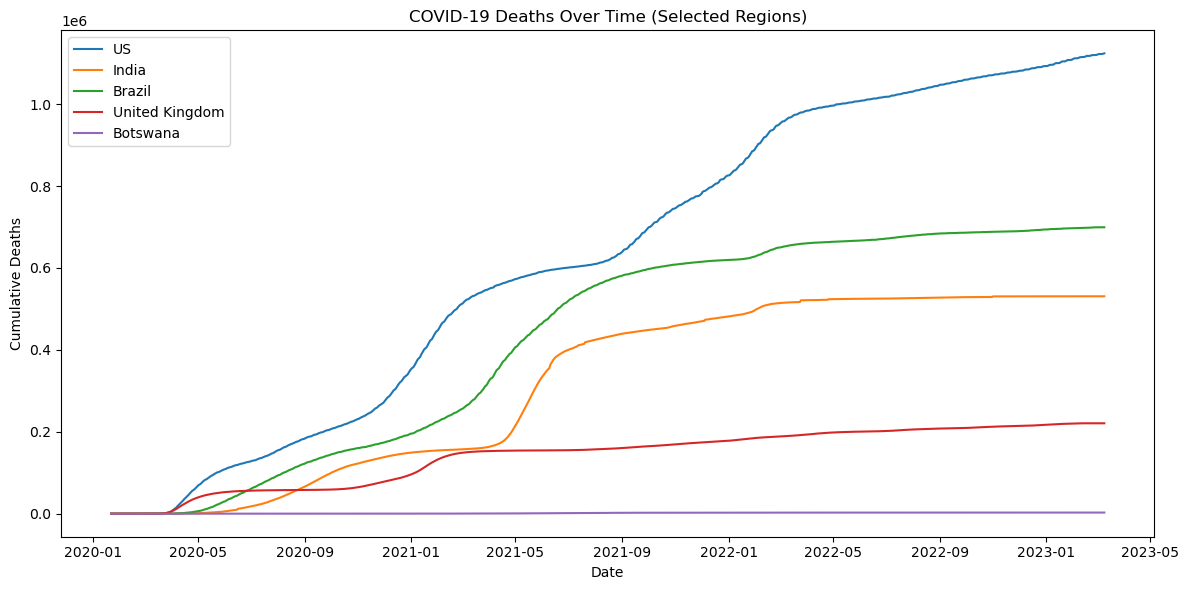

In [9]:
#do the same but for death(deaths overtime with regions)
plt.figure(figsize=(12, 6))

for country in selected_countries:
    selected_set = regions[regions["Country/Region"] == country]
    plt.plot(selected_set["Date"], selected_set["Deaths"], label=country)

plt.title("COVID-19 Deaths Over Time (Selected Regions)")
plt.xlabel("Date")
plt.ylabel("Cumulative Deaths")
plt.legend()
plt.tight_layout()
plt.show()

**Confirmed Cases**
-The US has the highest cumulative cases by far, steep and steady growth.
-India, around 2021 and show spikes indicating sudden waves which may be a new varient.
-Brazil has slower growth than others forementioned, less spikes as well.
-UK shows spikes but stil has relayively slow growth.
-Botswana rmains quite low which may be due to the scale.

**Conclusion**
High populations possibly lead to high rate of spreading of the virus (US and India).
Sudden spikes may have been a varient(Omicron).
But if something a s high movement and population density affect the spreading rate then measures like lockdown are bound to curb these rates bringing them down.

**Deaths**
Here we still see the pattern noticed above still persisiting, US>India>Brazil>UK>Botswana.
BUt Brazil has higheer death rate than the spreadingb rate which communicates high fatality ratio. But for almost countries there's still sudden spikes which correspond to spikes in confirmed cases.


In [10]:
'''
Check the distribution of cases with plots of Rolling mean and standard deviation
Rolling Std
Stability (how consistent the spread is)
Rolling Mean
Trend (direction of pandemic)
'''
#compute daily cases and daily deaths as per regions or countries
countries["Daily Cases1"] = countries.groupby("Country/Region")["Confirmed"].diff()
countries["Daily Deaths"] = countries.groupby("Country/Region")["Deaths"].diff()

In [11]:
#DAILY CASES AT REGIONAL LEVEL
#rolling mean cases per region
countries["Rolling Mean Cases1"] = (
    countries.groupby("Country/Region")["Daily Cases1"].rolling(7).mean().reset_index(level=0, drop=True))

#creating roll std cases per region to plot
countries["Rolling Std Cases1"] = (
    countries.groupby("Country/Region")["Daily Cases1"].rolling(7).std().reset_index(level=0, drop=True))
countries.columns

Index(['Country/Region', 'Date', 'Confirmed', 'Deaths', 'Daily Cases1',
       'Daily Deaths', 'Rolling Mean Cases1', 'Rolling Std Cases1'],
      dtype='object')

In [12]:
#DAILY CASES AT REGIONAL LEVEL
#rolling mean cases per region
countries["Rolling Mean Deaths"] = (
    countries.groupby("Country/Region")["Daily Cases1"].rolling(7).mean().reset_index(level=0, drop=True))

#creating roll std cases per region to plot
countries["Rolling Std Deaths"] = (
    countries.groupby("Country/Region")["Daily Cases1"].rolling(7).std().reset_index(level=0, drop=True))

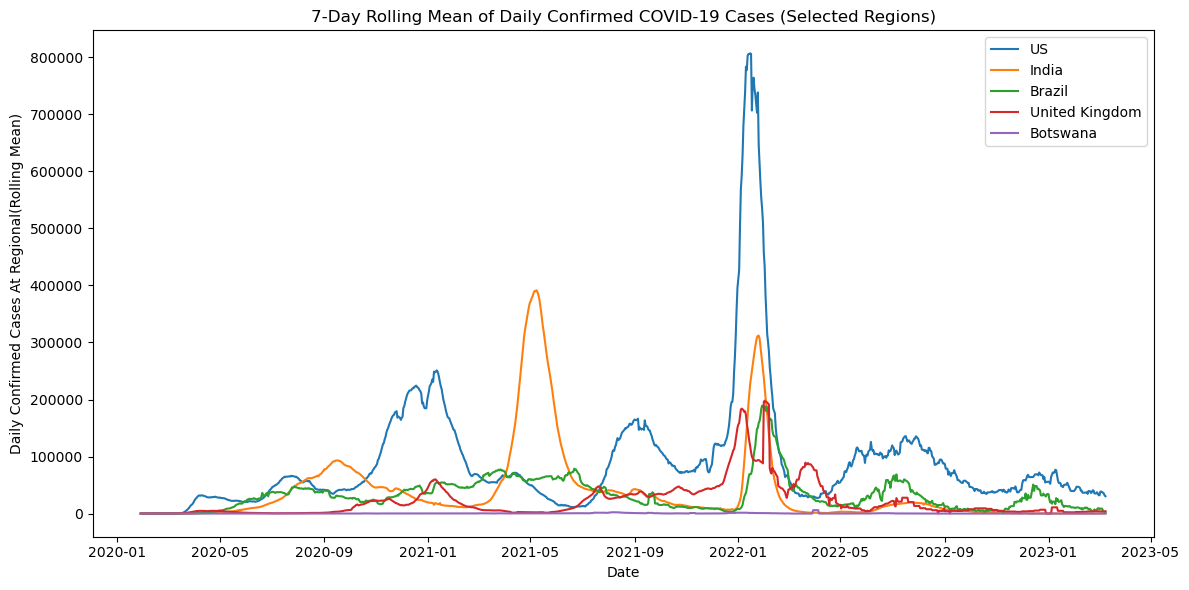

In [13]:
#PLOTTING ROLLING STATS FOR REGIONAL LEVEL, DAILY DEATHS AND DAILY CONFIRMED CASES

#rolling mean plot with region for Daily Confirmed Cases
plt.figure(figsize=(12, 6))

for country in selected_countries:
    selected_set = countries[countries["Country/Region"] == country]
    plt.plot(selected_set["Date"], selected_set["Rolling Mean Cases1"], label=country)

plt.title("7-Day Rolling Mean of Daily Confirmed COVID-19 Cases (Selected Regions)")
plt.xlabel("Date")
plt.ylabel("Daily Confirmed Cases At Regional(Rolling Mean)")
plt.legend()
plt.tight_layout()
plt.show()

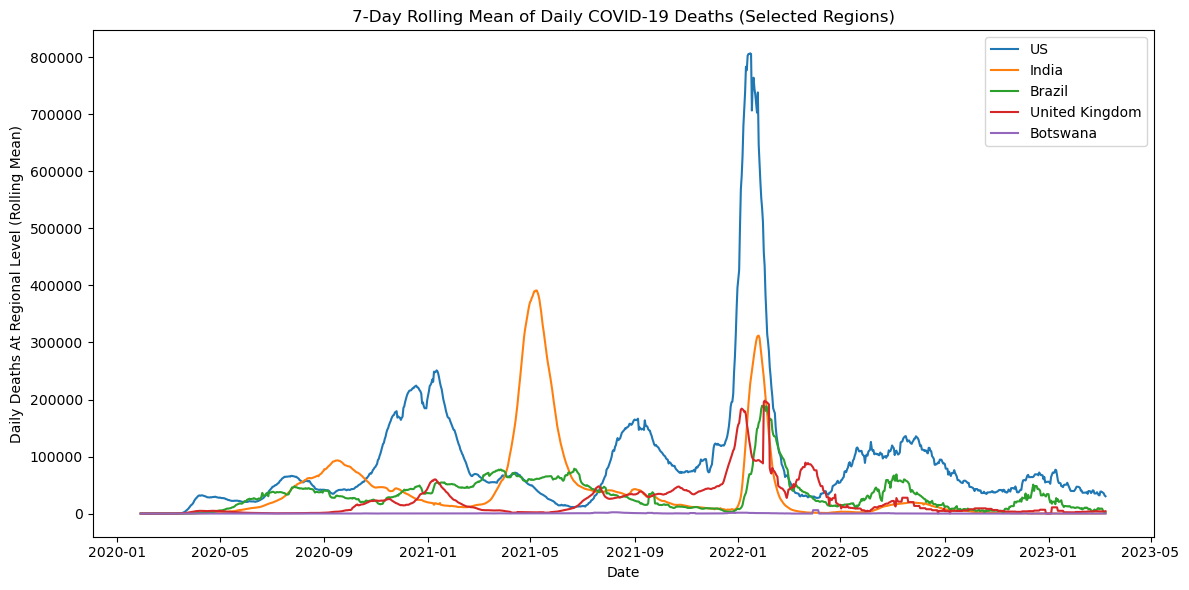

In [14]:
#rolling mean plot with region for Daily Deaths
plt.figure(figsize=(12, 6))

for country in selected_countries:
    selected_set = countries[countries["Country/Region"] == country]
    plt.plot(
        selected_set["Date"],
        selected_set["Rolling Mean Deaths"],
        label=country
    )

plt.title("7-Day Rolling Mean of Daily COVID-19 Deaths (Selected Regions)")
plt.xlabel("Date")
plt.ylabel("Daily Deaths At Regional Level (Rolling Mean)")
plt.legend()
plt.tight_layout()
plt.show()

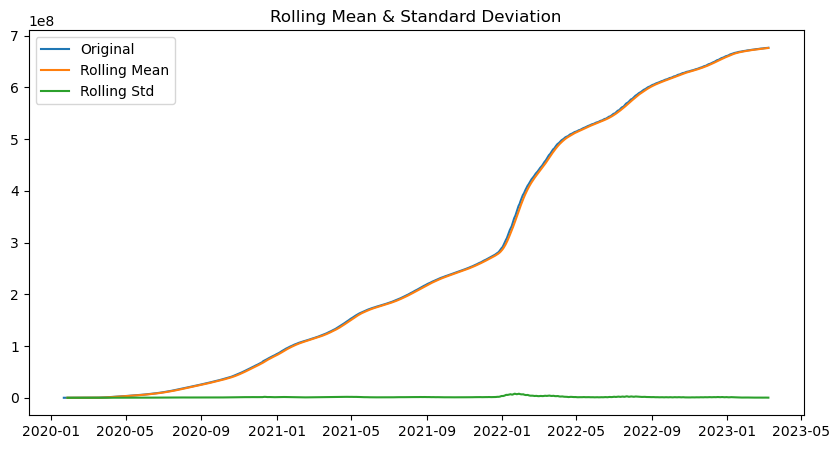

In [15]:
#do the same but at a global level
globe["Rolling Mean"] = globe["Confirmed"].rolling(7).mean()
globe["Rolling Std"] = globe["Confirmed"].rolling(7).std()
globe.columns

#plots
plt.figure(figsize=(10,5))
plt.plot(globe["Date"], globe["Confirmed"], label="Original")
plt.plot(globe["Date"], globe["Rolling Mean"], label="Rolling Mean")
plt.plot(globe["Date"], globe["Rolling Std"], label="Rolling Std")

plt.legend()
plt.title("Rolling Mean & Standard Deviation")
plt.show()

**Interpretations**
At the global level there is an upward trend in the original and the rolling mean but the std deviation is seemingly constant except for the bump at around 2022, which is in line with the hump in the orginal data and the mean.

But there being an upward trend leads to a conclusion of the data being non-stationary, lading to the next step of differencing or calculating daily changes isntead of cumulative. For tis a column daily_cases will be created. 

In [16]:
#COMPUTE Daily Cases
globe["Daily Cases"] = globe["Confirmed"].diff()
#DIFFERENCING-this will tell us the rate at which te cases are increasing
globe["Diff Cases"] = globe["Daily Cases"].diff()
globe.head()

,Date,Confirmed,Deaths,Rolling Mean,Rolling Std,Daily Cases,Diff Cases
0,2020-01-22,557,17,NaN,NaN,NaN,NaN
1,2020-01-23,657,18,NaN,NaN,100.0,NaN
2,2020-01-24,944,26,NaN,NaN,287.0,187.0
3,2020-01-25,1437,42,NaN,NaN,493.0,206.0
4,2020-01-26,2120,56,NaN,NaN,683.0,190.0


The way daily cases are determined is by: confirmed1- confirmed2
and diff cases by:(confirmed1- confirmed2) - (confirmed2-confirmed3), and so on and so forth, making daily cases first oder differencing and diff cases second order. The reason for this is given below.

ADF Statistic: -3.0446292989110417
p-value: 0.03093159662542175

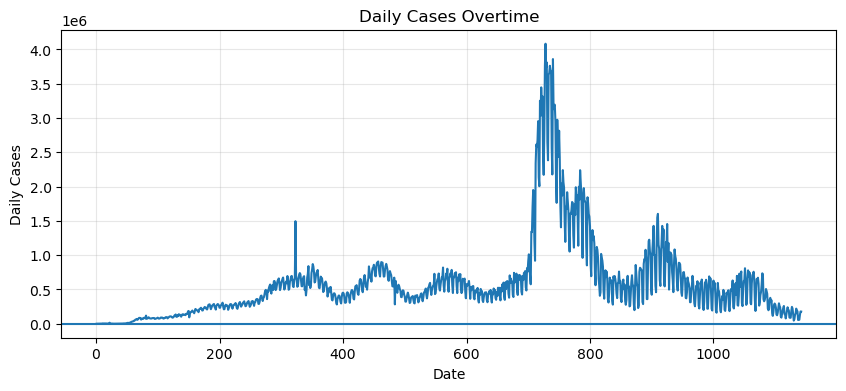

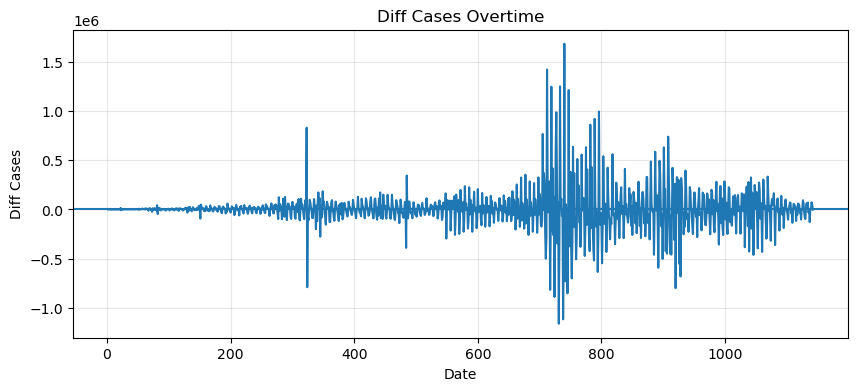

In [17]:
globe['Daily Cases'].plot(figsize=(10,4))
plt.axhline(0)
plt.title('Daily Cases Overtime')
plt.xlabel('Date')
plt.ylabel('Daily Cases')
plt.grid(alpha=0.3)
plt.show()

globe['Diff Cases'].plot(figsize=(10,4))
plt.axhline(0)
plt.title('Diff Cases Overtime')
plt.xlabel('Date')
plt.ylabel('Diff Cases')
plt.grid(alpha=0.3)
plt.show()

**Interprtation**
Daily cases is not stationary as
-varying mean
-it also shows seasonality with waves, high flactuations which means the variance is still high

Diff cases on one and:
-values oscillate around zero
-has constant mean with no trend
-there's a presence of waves which means variance is still high

In [18]:
#perform ADF
from statsmodels.tsa.stattools import adfuller

daily_adf = adfuller(globe["Daily Cases"].dropna())
print("ADF Statistic for Daily Cases:", daily_adf[0])
print("p-value for Daily Cases:", daily_adf[1])

ADF Statistic for Daily Cases: -3.0446292989110417
p-value for Daily Cases: 0.03093159662542175


In [19]:
diff_adf = adfuller(globe["Diff Cases"].dropna()) 
print("ADF Statistic for Diff Cases:", diff_adf[0]) 
print("p-value for Diff Cases:", diff_adf[1])

ADF Statistic for Diff Cases: -6.658580945039432
p-value for Diff Cases: 4.912409480071619e-09


ADF Statistic for Daily Cases: -3.0446292989110417
p-value for Daily Cases: 0.03093159662542175

ADF Statistic for Diff Cases: -6.658580945039432
p-value for Diff Cases: 4.912409480071619e-09

**iNTERPRETATION**
The daiky cases series has a p-value slightly below 0.05 indicating weak eviddence t reject the null hypothesis, but the diff cases series shows a very small number compared to 0.05, a high evidence to reject the null hypothesis. 
Whiich agrees with the charts that differencing (2nd order) removed the trend components making the time series suitable to be worked on by model.

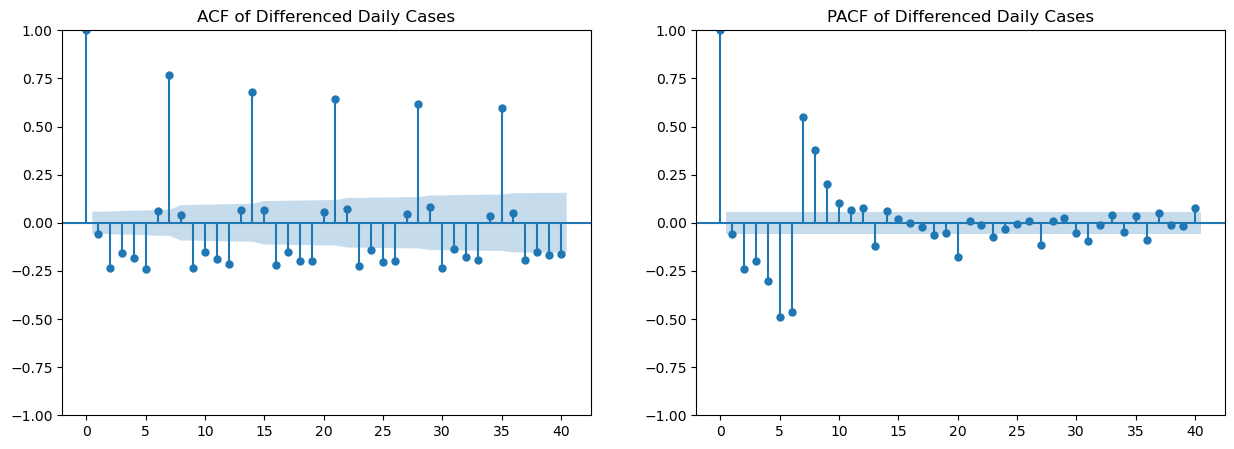

In [20]:
# Plot ACF and PACF for Diff Cases

# Import necessary libraries
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

diff_cases = globe["Diff Cases"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15,5))

# ACF plot
plot_acf(diff_cases, lags=40, ax=axes[0])
axes[0].set_title("ACF of Differenced Daily Cases")

# PACF plot
plot_pacf(diff_cases, lags=40, ax=axes[1], method='ywm')
axes[1].set_title("PACF of Differenced Daily Cases")

plt.show()

**Interpretation**

**ACF**
There are spikes at ~7, 14, 21, 28 and so on, which can be marked tol mean seasonality in Dialy Cases. And the spikes  not dying out might mean going further to another differencing as now we are on 2nd order differencing. And the spikes between 1 and 6 show a seasonal moving average.

**PACF**
There are very sharp spikes at 7 which seem to die down as you move further from it, this points to a seasonal AR of 1. And the unordered lags point to non seasonal AR. 

mODEL PARAMETERS:
-d=2 was used therefroe d value will be 2
-significant spikes at pacf lag 1 and 2, therefroe for AR 1 or 2 can be used
-For MA, 1 or 0 is fine a ACF shows initial significance but PACF dominates in trends.

But due to the trends in ACF SSARIMA is more suggestible than ARIMA.

In [21]:
 # Ensure 'Date' is datetime and set as index
globe['Date'] = pd.to_datetime(globe['Date'])
globe.set_index('Date', inplace=True)

# Use 'Diff Cases' or original 'Daily Cases' (we’ll model after differencing in SARIMA)
data = globe['Daily Cases'].dropna()

# Train-test split (80%-20%)
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

print(f"Train length: {len(train)}, Test length: {len(test)}")

Train length: 913, Test length: 229


The data is separated at ~80 to 20, for train and test data

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define the SARIMA model
model = SARIMAX(train,order=(0,1,1),           # non-seasonal (p,d,q)
    seasonal_order=(1,1,1,7), # seasonal (P,D,Q,s)
    enforce_stationarity=False,
    enforce_invertibility=False)

# Fit the model
model_fit = model.fit(disp=False)
print(model_fit.summary())

C:\Users\small\.conda\envs\ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\small\.conda\envs\ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                       Daily Cases   No. Observations:                  913
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -11656.813
Date:                           Thu, 26 Mar 2026   AIC                          23321.626
Time:                                   08:12:07   BIC                          23340.817
Sample:                               01-23-2020   HQIC                         23328.959
                                    - 07-23-2022                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5844      0.012    -50.765      0.000      -0.607      -0.562
ar.S.L7        0.6456      0.023     27.928

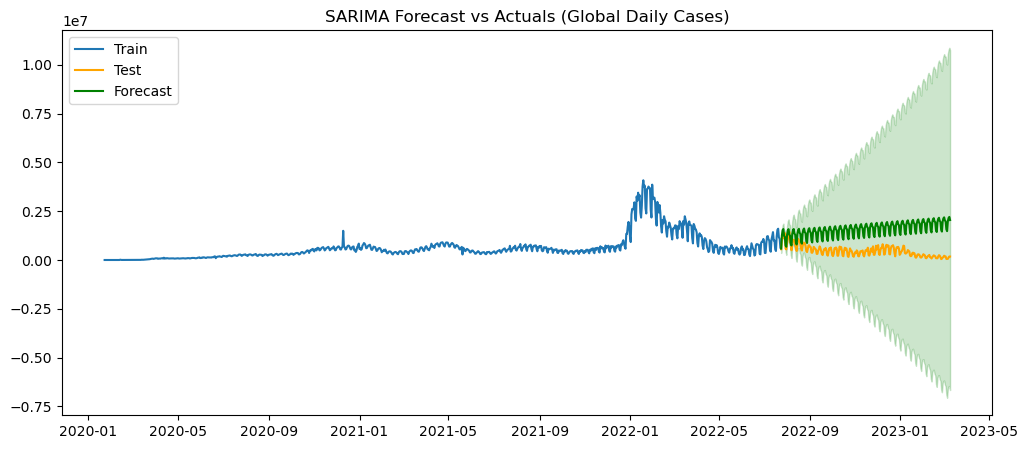

In [23]:
# Forecast for the length of the test set
forecast = model_fit.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot actual vs forecast
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast_mean, label='Forecast', color='green')
plt.fill_between(test.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='green', alpha=0.2)
plt.legend()
plt.title("SARIMA Forecast vs Actuals (Global Daily Cases)")
plt.show()

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test, forecast_mean))

# Calculate MAE (Mean Absolute Error) for comparison
mae = mean_absolute_error(test, forecast_mean)

print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")

# Calculate the error as a percentage of the average test value
mean_actual = test.mean()
print(f"Average Actual Cases: {mean_actual:,.2f}")
print(f"Error Percentage (RMSE/Mean): {(rmse/mean_actual)*100:.2f}%")

RMSE: 1,193,992.68
MAE:  1,108,928.89
Average Actual Cases: 465,963.84
Error Percentage (RMSE/Mean): 256.24%


**Interpretation**
Starting with the graph, it shows a trend as it gets of to the end during forecasting. The model also goes up which is probably because it registered the waves in. the data before forecasting (momentum).

Next we see RMSE of ~1.2M and MAE of ~1.1M, this is a very high percentage error, which can be tributed to that the model used is a linear model but the data still displays waves. Log transform might help with this.

## Forecasting and Insight Generation

### Future COVID-19 Case and Death Forecasts

Using global and regional time series data, overall COVID-19 trends indicate a persistent upward movement in confirmed cases and fatalities over time, punctuated by waves of rapid increases.

Rolling mean analysis shows smoother long-term trends, while rolling standard deviation captures periods of increased volatility going with outbreak means. Forecasting models built on differenced data are better suited for capturing short-term dynamics rather than long-term structural changes.

At the global level, forecasts suggest that case counts follow seasonal patterns rather than steady linear growth. At the regional level, forecasts vary significantly, with some countries showing prolonged periods of stability while others experience sharp surges eg. US. 

### Identification of High-Risk Regions

Regions with high-risk profiles were identified based on:
- Steep slopes in daily confirmed cases
- Sustained increases in rolling mean values
- Sudden spikes in rolling standard deviation

These indicators highlight regions undergoing rapid transmission phases. Peak fatality windows often lag behind peaks in confirmed cases, suggesting a delay between infection spread and mortality outcomes. This temporal separation is consistent across multiple regions and provides a useful signal for anticipating healthcare pressure.

### Impact of External Interventions

Several external factors influence the observed trends:

- Lockdowns and policy interventions often coincide with temporary reductions or plateaus in daily cases, visible as flattening in rolling mean curves.
- Reporting artifacts, such as batch updates or delays, introduce artificial spikes in daily values and inflate rolling standard deviation.
- Model fails to perform well during sudden outbreaks or reporting changes, where historical patterns fail to generalize to new dynamics.

These factors reduce forecast accuracy during high-volatility periods.

## 7. Key Insights

- Weekly seasonality dominates the data, likely driven by testing and exposure possibly during the weekdays when going to work or school.
- Predictability improves during stable periods, where trends evolve gradually and volatility is low.
- Forecasting models struggle during outbreak phases, where rapid behavioral, policy, or reporting changes introduce non-stationarity.

Rolling statistics and differencing proved essential in revealing these structural characteristics.

## 8. Policy Implications

- Early warning signals such as rising rolling standard deviation can indicate impending outbreak phases before peak case counts are observed.
- Resource allocation timing can be improved by monitoring lagged relationships between confirmed cases and fatalities.
- Improved data reporting practices, like consistent update schedules, would greatly improve modeling reliability and forecast accuracy.

Overall, though having shown great percentage errors, time series analysis provides valuable quantitative insights for monitoring pandemic progression, while highlighting the need for cautious interpretation during periods of instability. 